# 08 Implied volatility

Historical volatility, which we found in notebook 6, looks backwards to measure how volatile the stock has been. Conversely, implied volatility looks forward to see how volatile the market is going to be.
Given a market option price, implied volatility is the $\sigma$ that makes the Black-Scholes formula reproduce that price, and is the market's consensus forecast of future volatility.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime
from pricer import bs_pricing, implied_volatility

## Verify solver on a known price

In [2]:
Sof0  = 100
K     = 105
r     = 0.05
sigma = 0.20
T     = 1.0

bs_price  = bs_pricing(Sof0, K, r, sigma, T, option_type='call')
recovered = implied_volatility(bs_price, Sof0, K, r, T, option_type='call')

print(f"Input sigma        : {sigma:.6f}")
print(f"Black-Scholes price: ${bs_price:.6f}")
print(f"Recovered IV       : {recovered:.6f}")
print(f"Difference         : {abs(sigma - recovered):.2e}")

Input sigma        : 0.200000
Black-Scholes price: $8.021352
Recovered IV       : 0.200000
Difference         : 1.31e-09


## Pull real options data

In [3]:
ticker = yf.Ticker("AAPL")
hist   = ticker.history(period="1y")
hist.index = hist.index.tz_localize(None)
Sof0   = hist['Close'].iloc[-1]
r      = 0.05

print("Available expiries:")
for i, exp in enumerate(ticker.options):
    print(f"  [{i}] {exp}")

Available expiries:
  [0] 2026-03-18
  [1] 2026-03-20
  [2] 2026-03-23
  [3] 2026-03-25
  [4] 2026-03-27
  [5] 2026-04-02
  [6] 2026-04-10
  [7] 2026-04-17
  [8] 2026-04-24
  [9] 2026-05-01
  [10] 2026-05-15
  [11] 2026-06-18
  [12] 2026-07-17
  [13] 2026-08-21
  [14] 2026-09-18
  [15] 2026-10-16
  [16] 2026-11-20
  [17] 2026-12-18
  [18] 2027-01-15
  [19] 2027-03-19
  [20] 2027-06-17
  [21] 2027-12-17
  [22] 2028-01-21
  [23] 2028-03-17
  [24] 2028-12-15


In [4]:
expiry      = ticker.options[4]
expiry_date = datetime.strptime(expiry, "%Y-%m-%d")
T           = (expiry_date - datetime.today()).days / 365

chain = ticker.option_chain(expiry)
calls = chain.calls.copy()
puts  = chain.puts.copy()

print(f"AAPL price : ${Sof0:.2f}")
print(f"Expiry     : {expiry}  (T = {T:.3f} years, {T*365:.0f} days)")
print(f"Raw call strikes: {len(calls)}")

AAPL price : $254.23
Expiry     : 2026-03-27  (T = 0.022 years, 8 days)
Raw call strikes: 51


In [5]:
# clean and filter
calls['mid_price'] = (calls['bid'] + calls['ask']) / 2
puts['mid_price']  = (puts['bid']  + puts['ask'])  / 2

# keep liquid strikes within 30% of current price, mid > $0.50
calls = calls[
    (calls['volume'] > 0) &
    (calls['strike'] > Sof0 * 0.75) &
    (calls['strike'] < Sof0 * 1.25) &
    (calls['mid_price'] > 0.50)
].copy().reset_index(drop=True)

puts = puts[
    (puts['volume'] > 0) &
    (puts['strike'] > Sof0 * 0.75) &
    (puts['strike'] < Sof0 * 1.25) &
    (puts['mid_price'] > 0.50)
].copy().reset_index(drop=True)

print(f"Filtered call strikes: {len(calls)}")
print(f"Filtered put  strikes: {len(puts)}")
print(calls[['strike', 'bid', 'ask', 'mid_price', 'impliedVolatility']].head(8).round(4))

Filtered call strikes: 22
Filtered put  strikes: 27
   strike    bid    ask  mid_price  impliedVolatility
0   195.0  58.10  61.15     59.625             0.8638
1   200.0  53.10  56.10     54.600             0.7842
2   205.0  48.35  51.20     49.775             0.7695
3   210.0  43.20  46.05     44.625             0.6558
4   215.0  38.20  41.20     39.700             0.6084
5   220.0  33.25  35.85     34.550             0.5000
6   222.5  30.80  32.45     31.625             0.5559
7   225.0  29.25  30.30     29.775             0.5745


In [6]:
# compute IV row by row with explicit error reporting
def safe_iv(row, Sof0, r, T, option_type):
    try:
        iv = implied_volatility(row['mid_price'], Sof0, row['strike'], r, T, option_type)
        return iv
    except Exception as e:
        return np.nan

calls['our_iv'] = calls.apply(safe_iv, axis=1, args=(Sof0, r, T, 'call'))
puts['our_iv']  = puts.apply(safe_iv,  axis=1, args=(Sof0, r, T, 'put'))

print(f"Calls — solved: {calls['our_iv'].notna().sum()}  failed: {calls['our_iv'].isna().sum()}")
print(f"Puts  — solved: {puts['our_iv'].notna().sum()}   failed: {puts['our_iv'].isna().sum()}")

# show a sample to verify values look reasonable
print("\nSample call IV results:")
print(calls[['strike', 'mid_price', 'our_iv', 'impliedVolatility']].head(8).round(4))

Calls — solved: 21  failed: 1
Puts  — solved: 27   failed: 0

Sample call IV results:
   strike  mid_price  our_iv  impliedVolatility
0   195.0     59.625  0.8561             0.8638
1   200.0     54.600  0.7638             0.7842
2   205.0     49.775  0.7838             0.7695
3   210.0     44.625  0.6360             0.6558
4   215.0     39.700  0.6021             0.6084
5   220.0     34.550  0.4494             0.5000
6   222.5     31.625     NaN             0.5559
7   225.0     29.775  0.4841             0.5745


<bound method Axes.plot of <Axes: >>

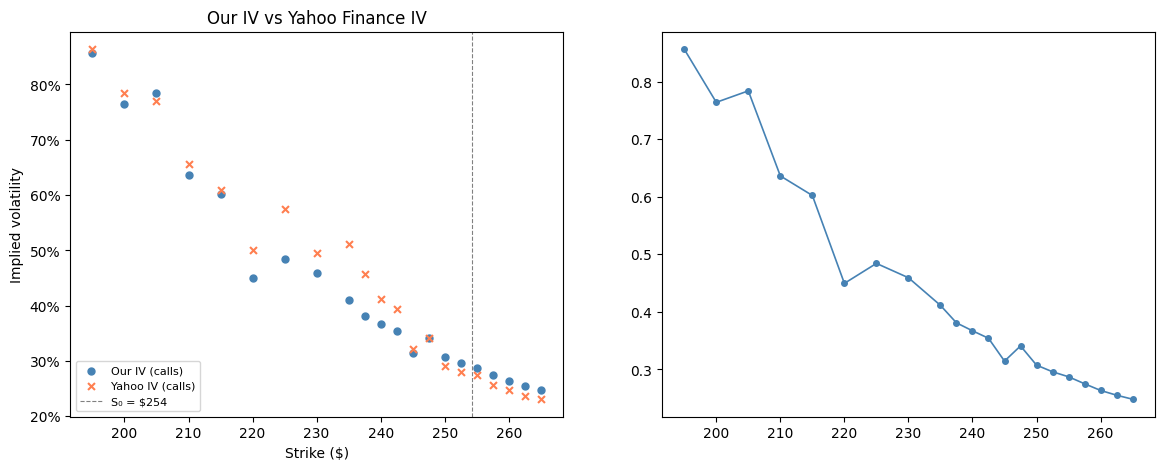

In [7]:
# drop fails
calls_clean = calls.dropna(subset=['our_iv'])
puts_clean  = puts.dropna(subset=['our_iv'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot 1: our IV vs yahoo's IV
axes[0].scatter(calls_clean['strike'], calls_clean['our_iv'],
                color='steelblue', s=25, label='Our IV (calls)')
axes[0].scatter(calls_clean['strike'], calls_clean['impliedVolatility'],
                color='coral', s=25, marker='x', linewidths=1.5,
                label='Yahoo IV (calls)')
axes[0].axvline(Sof0, color='gray', linestyle='--',
                linewidth=0.8, label=f'S₀ = ${Sof0:.0f}')
axes[0].set_xlabel('Strike ($)')
axes[0].set_ylabel('Implied volatility')
axes[0].set_title('Our IV vs Yahoo Finance IV')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].legend(fontsize=8)

# plot 2: volatility smile — calls and puts together
axes[1].plot(calls_clean['strike'], calls_clean['our_iv'],
             color='steelblue', linewidth=1.2, marker='o',
             markersize=4, label='Calls')
axes[1].plot

## Volatility term structure

ATM implied volatility plotted across all available expiries.
Shows whether near-term or long-term uncertainty is higher.

In [8]:
atm_ivs = []

for exp in ticker.options[:8]:
    try:
        exp_date = datetime.strptime(exp, "%Y-%m-%d")
        T_exp    = (exp_date - datetime.today()).days / 365

        if T_exp < 0.02:
            continue

        ch  = ticker.option_chain(exp)
        df  = ch.calls.copy()
        df['mid_price'] = (df['bid'] + df['ask']) / 2
        df  = df[df['mid_price'] > 0.50].copy()

        if len(df) == 0:
            continue

        # closest strike to ATM
        df['dist'] = abs(df['strike'] - Sof0)
        row        = df.loc[df['dist'].idxmin()]
        iv         = implied_volatility(row['mid_price'], Sof0,
                                        row['strike'], r, T_exp, 'call')

        if not np.isnan(iv):
            atm_ivs.append({'expiry': exp, 'days': T_exp * 365, 'iv': iv})

    except Exception:
        continue

ts = pd.DataFrame(atm_ivs)
print(ts.round(4))

       expiry  days      iv
0  2026-03-27   8.0  0.2872
1  2026-04-02  14.0  0.2674
2  2026-04-10  22.0  0.2461
3  2026-04-17  29.0  0.2557


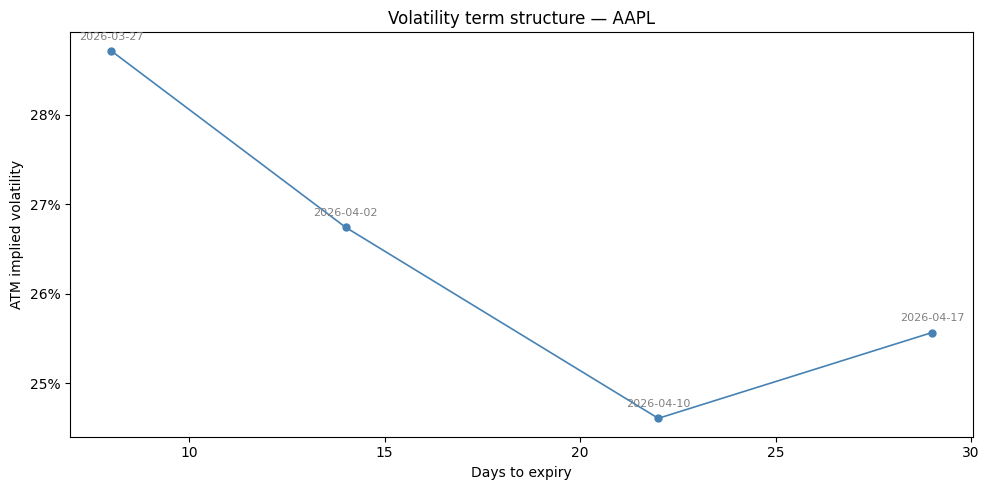

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(ts['days'], ts['iv'], color='steelblue', linewidth=1.2,
         marker='o', markersize=5)
for _, row in ts.iterrows():
    plt.annotate(row['expiry'], (row['days'], row['iv']),
                 textcoords='offset points', xytext=(0, 8),
                 fontsize=8, ha='center', color='gray')
plt.xlabel('Days to expiry')
plt.ylabel('ATM implied volatility')
plt.title('Volatility term structure — AAPL')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()

Looking at the sample output:

- Our IV closely tracks Yahoo's; the small differences are due to
  Yahoo using a different model and mid-price convention. Close enough
  to validate our solver is correct.

- The smile slopes downward; IV is highest for low strikes (deep
  ITM calls / OTM puts) and falls as strike rises. For equities this
  is called a *skew* rather than a smile — the market prices crash risk
  asymmetrically, paying more for downside protection than upside
  speculation.
- The term structure shows whether the market is more nervous about
  near-term or long-term moves. A steep upward slope means long-term
  uncertainty dominates; a downward slope (inverted term structure)
  often appears around earnings or macro events when short-dated vol spikes.